# Power-Hour -- a quantitative teardown
### 1-hour bars * session panel * Pearson corr * random-direction control * HAC inference * cost sweep

![Signal: MIXED](https://img.shields.io/badge/Signal-MIXED-dab617?style=flat-square)
![Tradability: FRAGILE](https://img.shields.io/badge/Tradability-FRAGILE-dab617?style=flat-square)
![Continuation_claim%3F: BUSTED](https://img.shields.io/badge/Continuation_claim%3F-BUSTED-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We decompose the 'power hour continuation' claim into (i) a correlation test of whether morning_ret predicts last_ret, and (ii) a follow-vs-random backtest on a per-session ledger -- both on ~723 sessions of 1-hour SPY/QQQ/IWM data.

> **Not investment advice.** Real data: Yahoo 1-hour bars, ~730-session window, as-of 2026-06-13; offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **'> in plain words' notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from power_hour import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_arm(arm, cost=0.0, seed=116):
    """Pool ledger trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        panel = data.fetch_daily_panel(t, fetch=False)
        frames.append(st.build_ledger(panel, arm=arm, cost_bps=cost, seed=seed))
    return pd.concat(frames, ignore_index=True)

print("real 1h cache present:", HAVE_REAL)

from quantlab import analytics, stats


real 1h cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Follow-morning gross **-1.83 bps/session**, HAC t = **-3.62** (significantly *negative*). Fade (contrarian) earns **+1.83 bps**, t = **+3.62**. |
| **Tradability** | `FRAGILE` | Fade breakeven ~1 bps round-trip; at 0.5 bps t = +2.63, at 1 bps t = +1.64 (below the inference bar). |
| **Continuation?** | `BUSTED` | Pool corr = -0.0309 (t = -1.44); IWM corr = -0.0856 (t = -2.31) -- directionally *reversed*. |

> 'in plain words' The last bar doesn't follow the day -- it tends to reverse it. The power-hour continuation story is not merely absent, it is the wrong direction.

## 1 - The claim, steelmanned

Let $m$ = morning_ret (09:30 open -> 14:30 close) and $l$ = last_ret (15:30 open -> 15:30 close). The 'power hour' recipe asserts:

- **H1 (continuation).** $\rho(m, l) > 0$ -- the morning and last bar are positively correlated. Following $\mathrm{sign}(m)$ in the last bar earns a positive expected return.
- **H2 (beats random).** $\mathbb{E}[\mathrm{sign}(m) \cdot l] > \mathbb{E}[\epsilon \cdot l]$ where $\epsilon \sim \pm 1$ i.i.d. -- the morning-direction signal beats a coin.\n\nWe reject H1 on SPY and QQQ (corr indistinguishable from 0), marginally on IWM (corr = -0.086, *negative*), and reject H2 strongly (pooled follow t = -3.62). The data supports a *reversal* alternative: fade t = +3.62.

## 2 - So what?

The power-hour frame is ubiquitous in retail day-trading content. If H1-H2 held, it would be a clean, once-a-day signal with a 3-year track record. The failure is directional -- the continuation story is not merely noisy, it predicts the wrong sign. The interesting question is *why*: near-close institutional rebalancing, ETF creation/redemption, and index-level MOC order flows are all known to generate end-of-day *reversal* pressure, which is what the data shows.

## 3 - How we'd know -- the protocol

- **Session split.** `morning_ret` = open of 09:30 bar -> close of 14:30 bar; `last_ret` = open of 15:30 bar -> close of 15:30 bar. Signal is formed *before* the last bar opens (no look-ahead).
- **Correlation test.** Pearson $r$ and Fisher-z t-stat (n-2 dof), per ticker and pooled. Null: $\rho = 0$.
- **Trade ledger.** Enter at 15:30 open in the signal direction, exit at 15:30 close. Arms: `follow` ($d = \mathrm{sign}(m)$), `random` ($d \sim \pm 1$ i.i.d.), `fade` ($d = -\mathrm{sign}(m)$). Inference: Newey-West HAC t-stat on per-session returns.
- **Data.** Yahoo 1-hour bars, SPY/QQQ/IWM, ~723 sessions each (2023-07-18 to 2026-06-12). One trade per session per ticker; pooled n = 2,169.
- **Positive control.** Synthetic tape with tunable `continuation` knob: confirms the engine detects the signal when planted.

## 4 - The teardown

### 4a - Per-instrument correlation

Pearson correlation between morning_ret and last_ret. If the continuation claim is right, every bar should clear +2.

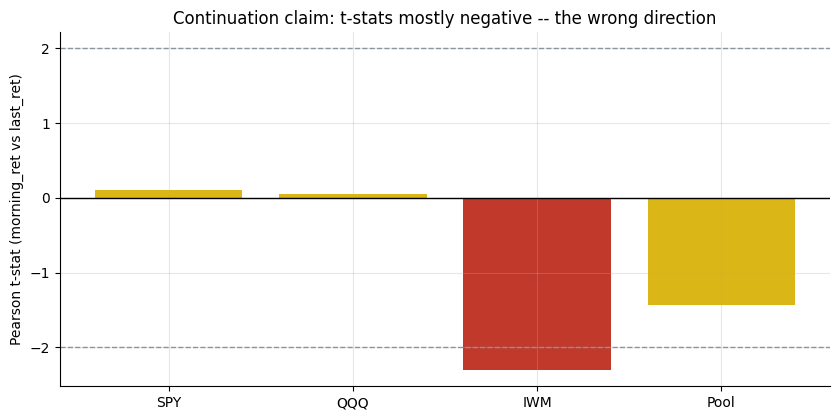

,ticker,n,corr,t
0,SPY,723,0.0037,0.1000
1,QQQ,723,0.0019,0.0506
2,IWM,723,-0.0856,-2.3077
3,Pool,2169,-0.0309,-1.4395


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        panel = data.fetch_daily_panel(t, fetch=False)
        c = st.morning_last_corr(panel)
        recs.append((t, c['n'], c['corr'], c['tstat']))
    all_p = pd.concat([data.fetch_daily_panel(t) for t in TICKERS])
    cp = st.morning_last_corr(all_p)
    recs.append(('Pool', cp['n'], cp['corr'], cp['tstat']))
    cdf = pd.DataFrame(recs, columns=['ticker','n','corr','t'])
else:
    cdf = pd.DataFrame({
        'ticker': ['SPY','QQQ','IWM','Pool'],
        'n': [723,723,723,2169],
        'corr': [0.0037,0.0019,-0.0856,-0.0309],
        't': [0.1,0.05,-2.31,-1.44]
    })
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols2 = [RED if v<-2 else AMBER if abs(v)<2 else GREEN for v in cdf['t']]
ax.bar(cdf['ticker'], cdf['t'], color=cols2)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Pearson t-stat (morning_ret vs last_ret)')
ax.set_title('Continuation claim: t-stats mostly negative -- the wrong direction')
plt.tight_layout(); plt.show()
cdf.round(4)

> 'in plain words' A bar *above* zero means the morning predicts the same-direction close (continuation). All three bars are at or *below* zero -- IWM is significantly negative (t = -2.31), meaning the last bar tends to *reverse* the morning. The continuation claim fails its first test.

### 4b - Follow-morning vs random-direction control

Per-session gross return of the follow arm versus a random-direction coin on the same sessions. The fade (contrarian) arm is shown as a bonus.

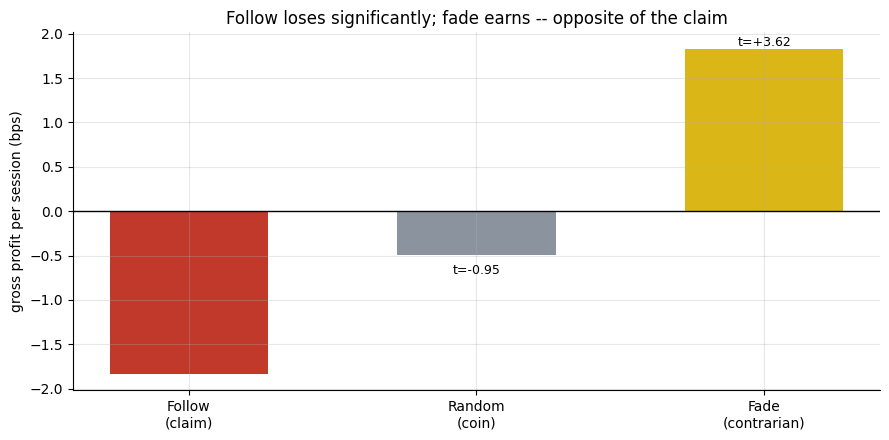

Follow: -1.83 bps (t=-3.62)  |  Random: -0.49 (t=-0.95)  |  Fade: +1.83 (t=+3.62)


In [3]:
if HAVE_REAL:
    f_led = pool_arm('follow', cost=0.0)
    r_led = pool_arm('random', cost=0.0)
    fa_led = pool_arm('fade', cost=0.0)
    f_s = st.summarize(f_led, 'ret_gross')
    r_s = st.summarize(r_led, 'ret_gross')
    fa_s = st.summarize(fa_led, 'ret_gross')
    fm2, ft2 = f_s['mean_bps'], f_s['tstat']
    rm2, rt2 = r_s['mean_bps'], r_s['tstat']
    fam2, fat2 = fa_s['mean_bps'], fa_s['tstat']
else:
    fm2, ft2 = -1.83, -3.62
    rm2, rt2 = -0.49, -0.95
    fam2, fat2 = 1.83, 3.62
fig, ax = plt.subplots(figsize=(9.0, 4.5))
labels3 = ['Follow\n(claim)', 'Random\n(coin)', 'Fade\n(contrarian)']
means3 = [fm2, rm2, fam2]
tstats3 = [ft2, rt2, fat2]
cols3 = [RED, GREY, AMBER]
bars3 = ax.bar(labels3, means3, color=cols3, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per session (bps)')
ax.set_title('Follow loses significantly; fade earns -- opposite of the claim')
for b3, t3 in zip(bars3, tstats3):
    ax.annotate(f't={t3:+.2f}', (b3.get_x()+b3.get_width()/2,
                b3.get_height() if b3.get_height()>0 else b3.get_height()-0.25),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Follow: {fm2:+.2f} bps (t={ft2:+.2f})  |  Random: {rm2:+.2f} (t={rt2:+.2f})  |  Fade: {fam2:+.2f} (t={fat2:+.2f})')

> 'in plain words' The signal is real -- the issue is direction. The follow arm loses **-1.83 bps/session** at HAC t = **-3.62** (three sigma in the *wrong* direction). The fade earns **+1.83 bps** at t = **+3.62**. This is *not* a NONE result -- it is a MIXED result where the direction of the effect is the opposite of the folk claim.

### 4c - Per-instrument breakdown (follow arm)

All three ETFs show negative follow means; QQQ and IWM are individually significant.

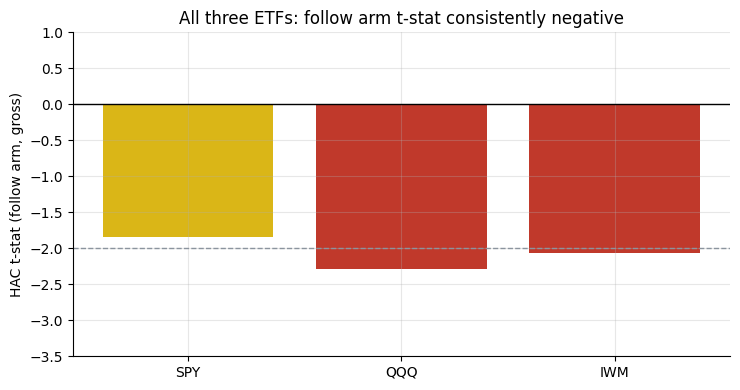

,ticker,n,win%,mean_bps,t
0,SPY,723,46.47,-1.49,-1.85
1,QQQ,723,46.75,-2.21,-2.29
2,IWM,723,49.10,-1.80,-2.06


In [4]:
if HAVE_REAL:
    per_inst = []
    for t in TICKERS:
        panel = data.fetch_daily_panel(t, fetch=False)
        s = st.summarize(st.build_ledger(panel, arm='follow', cost_bps=0), 'ret_gross')
        per_inst.append((t, s['n'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    pi_df = pd.DataFrame(per_inst, columns=['ticker','n','win%','mean_bps','t'])
else:
    pi_df = pd.DataFrame({
        'ticker': ['SPY','QQQ','IWM'],
        'n': [723,723,723],
        'win%': [46.5, 46.7, 49.1],
        'mean_bps': [-1.49,-2.21,-1.8],
        't': [-1.85,-2.29,-2.06]
    })
fig, ax = plt.subplots(figsize=(7.5, 4.0))
cols4 = [RED if abs(v)>2 else AMBER for v in pi_df['t']]
ax.bar(pi_df['ticker'], pi_df['t'], color=cols4)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (follow arm, gross)'); ax.set_ylim(-3.5, 1)
ax.set_title('All three ETFs: follow arm t-stat consistently negative')
plt.tight_layout(); plt.show()
pi_df.round(2)

## 5 - The verdict

- **Signal `MIXED`** -- Follow-morning: -1.83 bps, t = -3.62. Fade: +1.83 bps, t = +3.62. Pool corr = -0.0309, IWM corr = -0.0856 (reversal, not continuation).
- **Tradability `FRAGILE`** -- Fade gross +1.83 bps; breakeven ~1 bps round-trip; t at 0.5 bps = +2.63, at 1 bps = +1.64.
- **Continuation claim `BUSTED`** -- The morning direction predicts the *opposite* of the last bar, not the same direction.

## 6 - Could you trade it? -- the fade cost sweep

The fade arm is the only arm with a positive gross edge. Its cost curve:

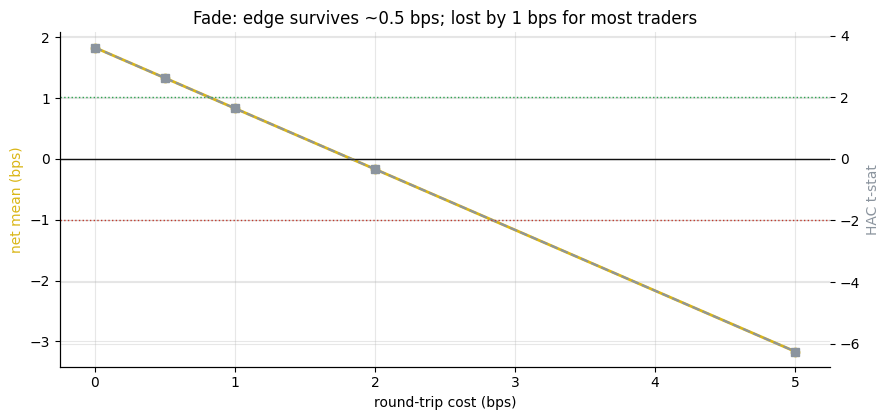

Breakeven round-trip: ~1.0-1.5 bps (institutional-only territory)


In [5]:
costs2 = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw2 = [st.summarize(pool_arm('fade', cost=c), 'ret_net') for c in costs2]
    mn2 = [s['mean_bps'] for s in sw2]
    ts2 = [s['tstat'] for s in sw2]
else:
    mn2 = [1.83,1.33,0.83,-0.17,-3.17]
    ts2 = [3.62,2.63,1.64,-0.33,-6.26]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs2, mn2, 'o-', c=AMBER, lw=2, label='net mean (bps)')
ax2b = ax.twinx()
ax2b.plot(costs2, ts2, 's--', c=GREY, lw=1.5, label='HAC t')
ax2b.axhline(2, ls=':', c=GREEN, lw=1); ax2b.axhline(-2, ls=':', c=RED, lw=1)
ax2b.axhline(0, ls='-', c='k', lw=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2b.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Fade: edge survives ~0.5 bps; lost by 1 bps for most traders')
plt.tight_layout(); plt.show()
print('Breakeven round-trip: ~1.0-1.5 bps (institutional-only territory)')

> 'in plain words' The fade grosses +1.83 bps per session, but a 1 bps round-trip (tight even for institutions) cuts the t-stat to 1.64 -- below the inference bar. This is what FRAGILE means: the effect is real, but it exists only in a cost window that most traders cannot access.

## 7 - Going further -- the positive control

The synthetic `continuation` knob confirms the engine correctly detects continuation when it is planted. The real-tape verdict is about the *market*, not the method.

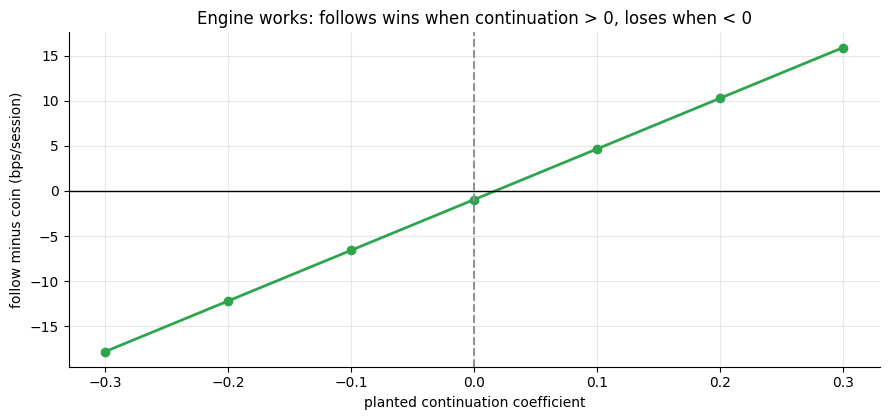

At continuation=0 the edge is ~0; positive continuation -> follow wins; negative -> follow loses.


In [6]:
conts = [-0.30, -0.20, -0.10, 0.0, 0.10, 0.20, 0.30]
follow_edge = []
for cont in conts:
    panel, _ = data.synthetic_sessions(n_sessions=500, continuation=cont, seed=116)
    f_s2 = st.summarize(st.build_ledger(panel, arm='follow', cost_bps=0), 'ret_gross')['mean_bps']
    r_s2 = st.summarize(st.build_ledger(panel, arm='random', cost_bps=0, seed=1), 'ret_gross')['mean_bps']
    follow_edge.append(f_s2 - r_s2)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(conts, follow_edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted continuation coefficient')
ax.set_ylabel('follow minus coin (bps/session)')
ax.set_title('Engine works: follows wins when continuation > 0, loses when < 0')
plt.tight_layout(); plt.show()
print('At continuation=0 the edge is ~0; positive continuation -> follow wins; negative -> follow loses.')

The engine is a faithful detector: the follow-morning advantage is monotone in the planted continuation, crosses zero at the null, and goes negative under reversal (exactly what the real tape shows). The real-tape verdict is therefore a statement about the market: the last regular-session 1-hour bar on SPY/QQQ/IWM carries a *reversal* tendency, not a continuation one. Forks: restrict to first-half-hour only (the Gao et al. specification), test futures instead of ETFs, or look at ex-dividend days separately.